In [108]:
import pandas as pd
import numpy as np
file_path=r'C:\Users\user\DL\HeartDiseasesUCI_BinaryPredic_DL\HeartDiseaseUCI.csv'
hd=pd.read_csv(file_path) #heart diseases=hd
hd.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [33]:
hd.count()
hd.dtypes
hd.shape

(1025, 14)

In [8]:
#print(hdf)

      age     sex  chest_pain_type  resting_blood_pressure  cholestoral  \
0      52    Male   Typical angina                     125          212   
1      53    Male   Typical angina                     140          203   
2      70    Male   Typical angina                     145          174   
3      61    Male   Typical angina                     148          203   
4      62  Female   Typical angina                     138          294   
...   ...     ...              ...                     ...          ...   
1020   59    Male  Atypical angina                     140          221   
1021   60    Male   Typical angina                     125          258   
1022   47    Male   Typical angina                     110          275   
1023   50  Female   Typical angina                     110          254   
1024   54    Male   Typical angina                     120          188   

         fasting_blood_sugar               rest_ecg  Max_heart_rate  \
0       Lower than 120 mg/ml

In [35]:
#Kepp a copy of your dataset
hd_copy=hd.copy()
hd_copy.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [36]:
#Checking missing data
hd.isnull().sum()
hd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

In [86]:
hd.isnull().values.any()

np.False_

In [87]:
hd.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [39]:
#Data Preprocessing:

In [42]:
#Planning:
#Exc induce angina show yes no, we need then value 0, 1, ordinal encoding
#Blood sugar two types greater than 120 or lower so we can assign 0 and 1; ordinal encoding
#Sex: if Male female assign 0 1 then it means high low value, so to avoid we will do One-hot Encoding (equal value)
#Chest Pain: assign Ordinal value  bcz one has higher effect than others. so need Ordinal encoding
#Rest_ecg two type, so Assign 0 and 1> ordinal encoding
#slop matter: ordinal encoding
#Vessel color, no matter order so just custom mapping according to str value
#Thalassemia : Ordinal encoding
#

In [116]:
# If only two values of data then we use Label encoder 0,1)- sex, blood sugar, induce_angina
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
hd['sex']=le.fit_transform(hd ['sex'])
print(hd['sex'])

0       1
1       1
2       1
3       1
4       0
       ..
1020    1
1021    1
1022    1
1023    0
1024    1
Name: sex, Length: 1025, dtype: int64


In [109]:
hd['fasting_blood_sugar']=le.fit_transform (hd['fasting_blood_sugar'])
hd['exercise_induced_angina']=le.fit_transform(hd['exercise_induced_angina'])
print(hd['fasting_blood_sugar'])


0       1
1       0
2       1
3       1
4       0
       ..
1020    1
1021    1
1022    1
1023    1
1024    1
Name: fasting_blood_sugar, Length: 1025, dtype: int64


In [110]:
#Ordinal encoding for data mapping according to order (When more than two values)
#chest_pain_type   Typical angina  Non-anginal pain
#one hot Encoding (to avoid weight impact (dont must needed for DL but need for ML
import pandas as pd

hd=pd.get_dummies(hd, columns=['chest_pain_type','slope'])
hd.head()
print(hd.columns)


Index(['age', 'sex', 'resting_blood_pressure', 'cholestoral',
       'fasting_blood_sugar', 'rest_ecg', 'Max_heart_rate',
       'exercise_induced_angina', 'oldpeak', 'vessels_colored_by_flourosopy',
       'thalassemia', 'target', 'chest_pain_type_Asymptomatic',
       'chest_pain_type_Atypical angina', 'chest_pain_type_Non-anginal pain',
       'chest_pain_type_Typical angina', 'slope_Downsloping', 'slope_Flat',
       'slope_Upsloping'],
      dtype='object')


In [55]:
hd.head()

,age,sex,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,vessels_colored_by_flourosopy,thalassemia,target,chest_pain_type_Asymptomatic,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,slope_Downsloping,slope_Flat,slope_Upsloping
0,52,1,125,212,1,ST-T wave abnormality,168,0,1.0,Two,Reversable Defect,0,False,False,False,True,True,False,False
1,53,1,140,203,0,Normal,155,1,3.1,Zero,Reversable Defect,0,False,False,False,True,False,False,True
2,70,1,145,174,1,ST-T wave abnormality,125,1,2.6,Zero,Reversable Defect,0,False,False,False,True,False,False,True
3,61,1,148,203,1,ST-T wave abnormality,161,0,0.0,One,Reversable Defect,0,False,False,False,True,True,False,False
4,62,0,138,294,0,ST-T wave abnormality,106,0,1.9,Three,Fixed Defect,0,False,False,False,True,False,True,False


In [111]:
#one Hot encoding kore boolean value a   m100sche so segu;ake 0,1 e nite hobe.
hd['chest_pain_type_Atypical angina']= hd['chest_pain_type_Atypical angina'].astype(int)
hd['chest_pain_type_Non-anginal pain']= hd['chest_pain_type_Non-anginal pain'].astype(int)
hd['chest_pain_type_Typical angina']= hd['chest_pain_type_Typical angina'].astype(int)
hd['slope_Downsloping']= hd['slope_Downsloping'].astype(int)
hd['slope_Flat']= hd['slope_Flat'].astype(int)
hd['slope_Upsloping']= hd['slope_Upsloping'].astype(int)
hd['chest_pain_type_Asymptomatic']=hd['chest_pain_type_Asymptomatic'].astype(int)
hd.head()

,age,sex,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,vessels_colored_by_flourosopy,thalassemia,target,chest_pain_type_Asymptomatic,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,slope_Downsloping,slope_Flat,slope_Upsloping
0,52,Male,125,212,1,ST-T wave abnormality,168,0,1.0,Two,Reversable Defect,0,0,0,0,1,1,0,0
1,53,Male,140,203,0,Normal,155,1,3.1,Zero,Reversable Defect,0,0,0,0,1,0,0,1
2,70,Male,145,174,1,ST-T wave abnormality,125,1,2.6,Zero,Reversable Defect,0,0,0,0,1,0,0,1
3,61,Male,148,203,1,ST-T wave abnormality,161,0,0.0,One,Reversable Defect,0,0,0,0,1,1,0,0
4,62,Female,138,294,0,ST-T wave abnormality,106,0,1.9,Three,Fixed Defect,0,0,0,0,1,0,1,0


In [112]:
#seg_mapping={'ST-T wave abnormality': 1,'Normal': 0,}
hd['rest_ecg']=le.fit_transform(hd['rest_ecg'])

In [93]:
import pandas as pd
#hd['vessels_colored_by_flourosopy'] = hd['vessels_colored_by_flourosopy'].str.strip().str.title() #to make case not sensitive
#color_mapping = {'Zero':0, 'One':1, 'Two':2, 'Three':3, 'Four':4}
#hd['vessels_colored_by_flourosopy'] = hd['vessels_colored_by_flourosopy'].map(color_mapping)
hd.head()

,age,sex,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,vessels_colored_by_flourosopy,thalassemia,target,chest_pain_type_Asymptomatic,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,slope_Downsloping,slope_Flat,slope_Upsloping
0,52,1,125,212,1,2,168,0,1.0,Two,Reversable Defect,0,False,0,0,1,1,0,0
1,53,1,140,203,0,1,155,1,3.1,Zero,Reversable Defect,0,False,0,0,1,0,0,1
2,70,1,145,174,1,2,125,1,2.6,Zero,Reversable Defect,0,False,0,0,1,0,0,1
3,61,1,148,203,1,2,161,0,0.0,One,Reversable Defect,0,False,0,0,1,1,0,0
4,62,0,138,294,0,2,106,0,1.9,Three,Fixed Defect,0,False,0,0,1,0,1,0


In [94]:
hd['vessels_colored_by_flourosopy'].unique()

array(['Two', 'Zero', 'One', 'Three', 'Four'], dtype=object)

In [95]:
hd_color=hd.copy()
hd.head()

,age,sex,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,vessels_colored_by_flourosopy,thalassemia,target,chest_pain_type_Asymptomatic,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,slope_Downsloping,slope_Flat,slope_Upsloping
0,52,1,125,212,1,2,168,0,1.0,Two,Reversable Defect,0,False,0,0,1,1,0,0
1,53,1,140,203,0,1,155,1,3.1,Zero,Reversable Defect,0,False,0,0,1,0,0,1
2,70,1,145,174,1,2,125,1,2.6,Zero,Reversable Defect,0,False,0,0,1,0,0,1
3,61,1,148,203,1,2,161,0,0.0,One,Reversable Defect,0,False,0,0,1,1,0,0
4,62,0,138,294,0,2,106,0,1.9,Three,Fixed Defect,0,False,0,0,1,0,1,0


In [113]:
color_mapping= {'Two':2, 'Zero':0, 'One':1, 'Three':3, 'Four':4}
hd_color['vessels_colored_by_flourosopy']=hd_color['vessels_colored_by_flourosopy'].map(color_mapping)
hd_color.head()

,age,sex,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,vessels_colored_by_flourosopy,thalassemia,target,chest_pain_type_Asymptomatic,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,slope_Downsloping,slope_Flat,slope_Upsloping
0,52,1,125,212,1,2,168,0,1.0,NaN,Reversable Defect,0,False,0,0,1,1,0,0
1,53,1,140,203,0,1,155,1,3.1,NaN,Reversable Defect,0,False,0,0,1,0,0,1
2,70,1,145,174,1,2,125,1,2.6,NaN,Reversable Defect,0,False,0,0,1,0,0,1
3,61,1,148,203,1,2,161,0,0.0,NaN,Reversable Defect,0,False,0,0,1,1,0,0
4,62,0,138,294,0,2,106,0,1.9,NaN,Fixed Defect,0,False,0,0,1,0,1,0


In [114]:
hd['vessels_colored_by_flourosopy'] = hd['vessels_colored_by_flourosopy'].str.strip().str.title()

# 2. Mapping
color_mapping = {'Zero':0, 'One':1, 'Two':2, 'Three':3, 'Four':4}
hd['vessels_colored_by_flourosopy'] = hd['vessels_colored_by_flourosopy'].map(color_mapping)

# 3. Check
hd['vessels_colored_by_flourosopy'].unique()
hd.head()

,age,sex,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,vessels_colored_by_flourosopy,thalassemia,target,chest_pain_type_Asymptomatic,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,slope_Downsloping,slope_Flat,slope_Upsloping
0,52,Male,125,212,1,2,168,0,1.0,2,Reversable Defect,0,0,0,0,1,1,0,0
1,53,Male,140,203,0,1,155,1,3.1,0,Reversable Defect,0,0,0,0,1,0,0,1
2,70,Male,145,174,1,2,125,1,2.6,0,Reversable Defect,0,0,0,0,1,0,0,1
3,61,Male,148,203,1,2,161,0,0.0,1,Reversable Defect,0,0,0,0,1,1,0,0
4,62,Female,138,294,0,2,106,0,1.9,3,Fixed Defect,0,0,0,0,1,0,1,0


In [102]:
hd.head()

,age,sex,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,vessels_colored_by_flourosopy,thalassemia,target,chest_pain_type_Asymptomatic,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,slope_Downsloping,slope_Flat,slope_Upsloping
0,52,1,125,212,1,2,168,0,1.0,2,Reversable Defect,0,0,0,0,1,1,0,0
1,53,1,140,203,0,1,155,1,3.1,0,Reversable Defect,0,0,0,0,1,0,0,1
2,70,1,145,174,1,2,125,1,2.6,0,Reversable Defect,0,0,0,0,1,0,0,1
3,61,1,148,203,1,2,161,0,0.0,1,Reversable Defect,0,0,0,0,1,1,0,0
4,62,0,138,294,0,2,106,0,1.9,3,Fixed Defect,0,0,0,0,1,0,1,0


In [103]:

hd['thalassemia'].unique()


array(['Reversable Defect', 'Fixed Defect', 'Normal', 'No'], dtype=object)

In [117]:
hd['thalassemia'] = hd['thalassemia'].str.strip().str.title()
thala_mapping={'Reversable Defect':2, 'Fixed Defect':3, 'Normal':0, 'No':1}
hd['thalassemia'] = hd['thalassemia'].map(thala_mapping)
hd.head()

AttributeError: Can only use .str accessor with string values!

In [118]:
hd.head()

,age,sex,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,vessels_colored_by_flourosopy,thalassemia,target,chest_pain_type_Asymptomatic,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,slope_Downsloping,slope_Flat,slope_Upsloping
0,52,1,125,212,1,2,168,0,1.0,2,2,0,0,0,0,1,1,0,0
1,53,1,140,203,0,1,155,1,3.1,0,2,0,0,0,0,1,0,0,1
2,70,1,145,174,1,2,125,1,2.6,0,2,0,0,0,0,1,0,0,1
3,61,1,148,203,1,2,161,0,0.0,1,2,0,0,0,0,1,1,0,0
4,62,0,138,294,0,2,106,0,1.9,3,3,0,0,0,0,1,0,1,0


In [119]:
#Now> data cleaning done
#ei cleaned datar copy
hd_clean=hd.copy()
hd_clean.head()

,age,sex,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,vessels_colored_by_flourosopy,thalassemia,target,chest_pain_type_Asymptomatic,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,slope_Downsloping,slope_Flat,slope_Upsloping
0,52,1,125,212,1,2,168,0,1.0,2,2,0,0,0,0,1,1,0,0
1,53,1,140,203,0,1,155,1,3.1,0,2,0,0,0,0,1,0,0,1
2,70,1,145,174,1,2,125,1,2.6,0,2,0,0,0,0,1,0,0,1
3,61,1,148,203,1,2,161,0,0.0,1,2,0,0,0,0,1,1,0,0
4,62,0,138,294,0,2,106,0,1.9,3,3,0,0,0,0,1,0,1,0


<Axes: xlabel='target', ylabel='count'>

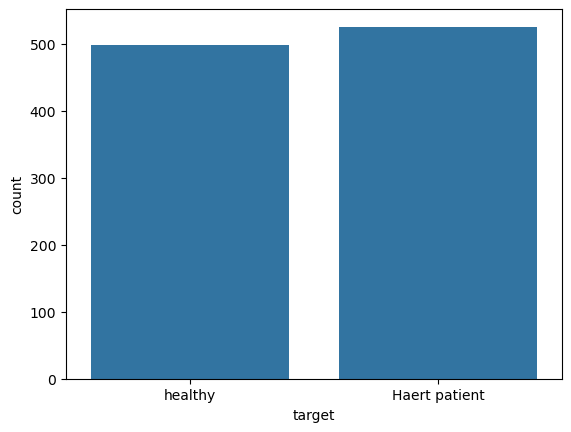

In [168]:
import seaborn as sns
hd_clean_df=hd_clean.copy()
hd_clean_df.target=hd_clean_df.target.map({0:'healthy', 1: 'Haert patient'})
sns.countplot(x='target', data=hd_clean_df)

In [122]:
#Feature scaling
from sklearn.preprocessing import StandardScaler
cols_to_scale = ['age','resting_blood_pressure','cholestoral','Max_heart_rate','oldpeak']
scaler = StandardScaler()
hd[cols_to_scale] = scaler.fit_transform(hd[cols_to_scale])
hd.head()


,age,sex,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,vessels_colored_by_flourosopy,thalassemia,target,chest_pain_type_Asymptomatic,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,slope_Downsloping,slope_Flat,slope_Upsloping
0,-0.268437,1,-0.377636,-0.659332,1,2,0.821321,0,-0.060888,2,2,0,0,0,0,1,1,0,0
1,-0.158157,1,0.479107,-0.833861,0,1,0.255968,1,1.727137,0,2,0,0,0,0,1,0,0,1
2,1.716595,1,0.764688,-1.396233,1,2,-1.048692,1,1.301417,0,2,0,0,0,0,1,0,0,1
3,0.724079,1,0.936037,-0.833861,1,2,0.516900,0,-0.912329,1,2,0,0,0,0,1,1,0,0
4,0.834359,0,0.364875,0.930822,0,2,-1.874977,0,0.705408,3,3,0,0,0,0,1,0,1,0


In [193]:
hd.shape
print(hd)

           age  sex  resting_blood_pressure  cholestoral  fasting_blood_sugar  \
0    -0.268437    1               -0.377636    -0.659332                    1   
1    -0.158157    1                0.479107    -0.833861                    0   
2     1.716595    1                0.764688    -1.396233                    1   
3     0.724079    1                0.936037    -0.833861                    1   
4     0.834359    0                0.364875     0.930822                    0   
...        ...  ...                     ...          ...                  ...   
1020  0.503520    1                0.479107    -0.484803                    1   
1021  0.613800    1               -0.377636     0.232705                    1   
1022 -0.819834    1               -1.234378     0.562371                    1   
1023 -0.488996    0               -1.234378     0.155137                    1   
1024 -0.047877    1               -0.663216    -1.124743                    1   

      rest_ecg  Max_heart_r

In [123]:
""Now DL Model steps:
1. spilt data for train test
2. Add layers
3. compile
4. Fit/Train model
5. Evaluate Model
6. Predict """

SyntaxError: unterminated triple-quoted string literal (detected at line 6) (1556936702.py, line 6)

In [129]:
# Split for train and testing
X= hd.drop('target', axis=1)
y=hd['target']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)

In [150]:
#Add layers
from keras.models import Sequential
from keras.layers import Dense
model=Sequential()
model.add(Dense(18, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [151]:
#Compile
model.compile(optimizer='adam', loss='binary_crossentropy' , metrics=['accuracy'])

In [154]:
#Fit/Train Model
history=model.fit(X_train,y_train, validation_split=0.2, epochs=80, batch_size=50)

Epoch 1/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9665 - loss: 0.1016 - val_accuracy: 0.9146 - val_loss: 0.2958
Epoch 2/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9680 - loss: 0.1009 - val_accuracy: 0.9146 - val_loss: 0.2981
Epoch 3/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9665 - loss: 0.1004 - val_accuracy: 0.9146 - val_loss: 0.2987
Epoch 4/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9665 - loss: 0.0992 - val_accuracy: 0.9146 - val_loss: 0.2944
Epoch 5/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9680 - loss: 0.0992 - val_accuracy: 0.9146 - val_loss: 0.2896
Epoch 6/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9695 - loss: 0.0989 - val_accuracy: 0.9146 - val_loss: 0.2992
Epoch 7/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9726 - loss: 0.0981 - val_accuracy: 0.9146 - val_loss: 0.2974
Epoch 8/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9726 - loss: 0.0964 - val_accuracy: 0.9146 - val_loss

In [171]:
#Evaluate model
loss,accuracy=model.evaluate(X_test,y_test)
print(loss,accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9171 - loss: 0.2411 
0.241102933883667 0.9170731902122498


In [172]:
loss,accuracy=model.evaluate(X_test,y_test)
print(loss,accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9171 - loss: 0.2411 
0.241102933883667 0.9170731902122498


In [ ]:
import seaborn as sns
sns.countplot

In [170]:
#predict
y_predict=model.predict(X_test)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [191]:
#test with real drandom data
import numpy as np
#Female	Typical angina	100	248	Lower than 120 mg/ml	Normal	122	No	1	Flat	Zero	Fixed Defect	1
Xnew=np.array([0,1,1,1,0,0,1,0,1,1,0,1], dtype=np.float64) 
#Xnew=np.array(Xnew, dtype=np.float64) 
Ynew=model.predict(Xnew) 
print(Ynew)
if Ynew>= 0.5:
    print("Heart Diseased")
else:
    print("Heart ok")

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
#acTUALLY I INPUT ONE ROW AND IT GIVES THE 0 OUTPUT SO MODEL IS OK ALMOST.

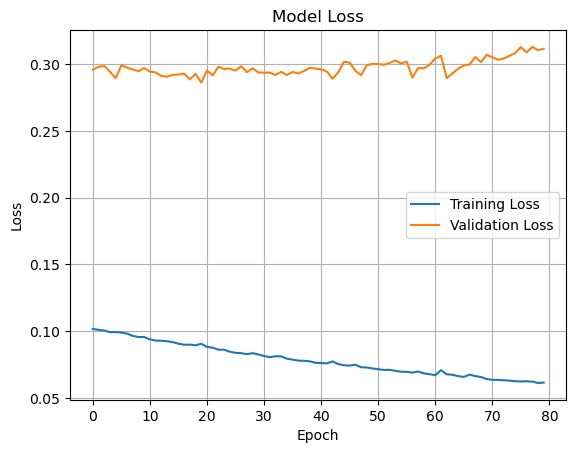

In [173]:
#Loss Plot (Training vs Validation)
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

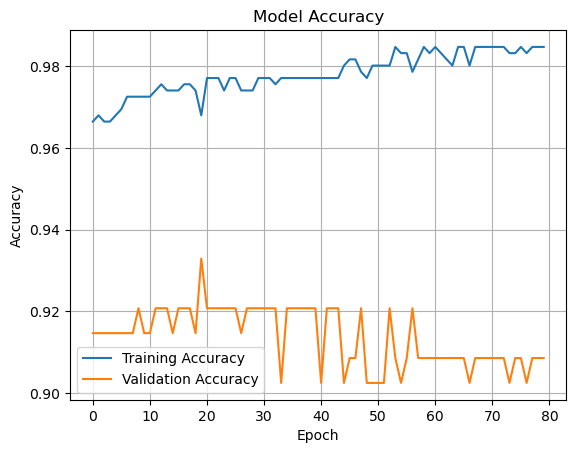

In [174]:
#Accuracy Plot (Training vs Validation)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

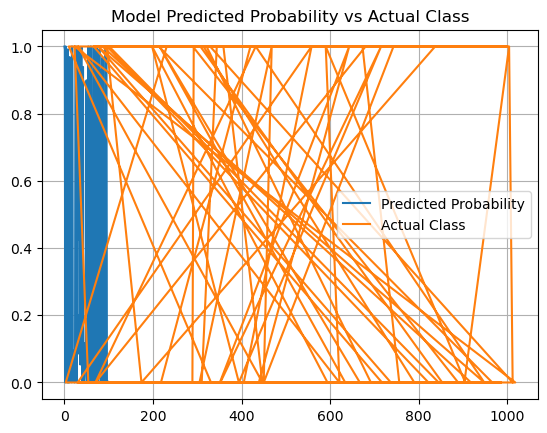

In [179]:
plt.plot(y_predict[:100], label='Predicted Probability')
plt.plot(y_test[:100], label='Actual Class')
plt.title("Model Predicted Probability vs Actual Class")
plt.legend()
plt.grid(True)
plt.show()